#### Moving Average Models

Seminar Temporal Modeling </br>
Leonie Schafferhans

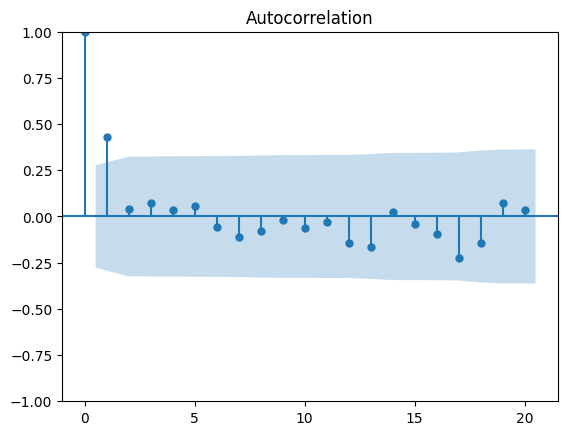

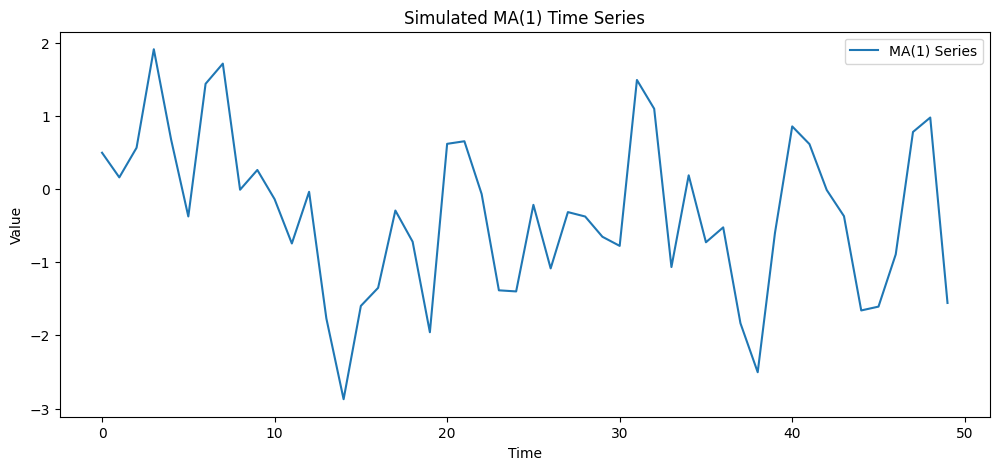

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   50
Model:                 ARIMA(0, 0, 1)   Log Likelihood                 -66.007
Date:                Wed, 17 Dec 2025   AIC                            138.014
Time:                        08:53:56   BIC                            143.750
Sample:                             0   HQIC                           140.198
                                 - 50                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3588      0.248     -1.446      0.148      -0.845       0.127
ma.L1          0.9259      0.103      8.991      0.000       0.724       1.128
sigma2         0.7894      0.155      5.088      0.0

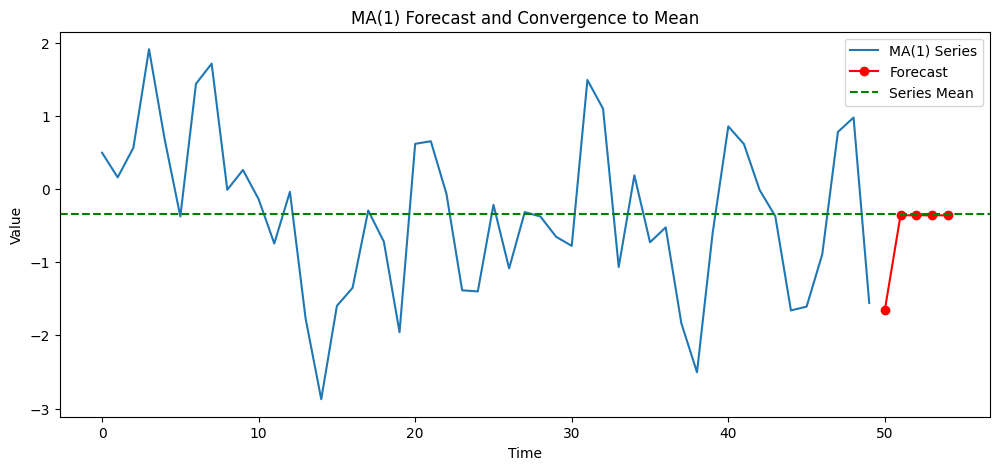

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf

# Simulate MA(1) process
np.random.seed(42)
e = np.random.normal(size=50) # 30 noise terms
y = e + 0.6 * np.roll(e, 1)  #  MA(1) = e_t + 0.6*e_(t-1)
y[0] = e[0]  # roll introduces NaN for first element


# plot acf
plot_acf(y, lags=20)
plt.show()


# Plot MA(1) series
plt.figure(figsize=(12,5))
plt.plot(y, label="MA(1) Series")
plt.title("Simulated MA(1) Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

# Fit MA(1) model
model = ARIMA(y, order=(0,0,1))   # (p,d,q) with p(Order of AR)=0, d (Differencing Count)=0, q (Order MA)=1  to ignore "ARI" components
fit = model.fit()
print(fit.summary())

# Forecast next 5 steps
forecast_steps = 5
forecast = fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
print("Forecast:", forecast_mean)

# Plot original series + forecast
plt.figure(figsize=(12,5))
plt.plot(y, label="MA(1) Series")
plt.plot(np.arange(len(y), len(y)+forecast_steps), forecast_mean, 'r-o', label="Forecast")


# Plot mean line
mean_value = y.mean()
plt.axhline(mean_value, color='green', linestyle='--', label="Series Mean")
plt.title("MA(1) Forecast and Convergence to Mean")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()


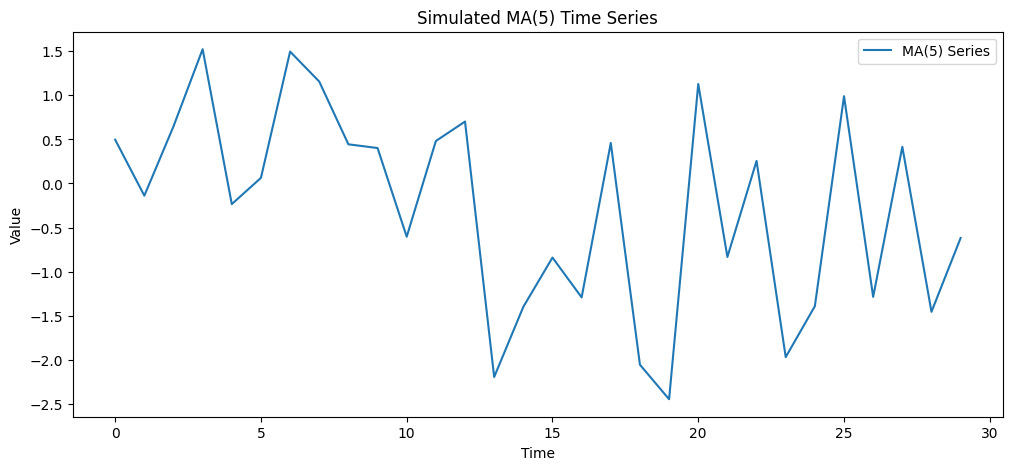

c:\Users\Leonie\miniconda3\envs\ch1\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   30
Model:                 ARIMA(0, 0, 5)   Log Likelihood                 -36.601
Date:                Wed, 17 Dec 2025   AIC                             87.202
Time:                        09:03:01   BIC                             97.010
Sample:                             0   HQIC                            90.340
                                 - 30                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2173      0.382     -0.569      0.569      -0.965       0.531
ma.L1          0.1303     22.820      0.006      0.995     -44.596      44.857
ma.L2          0.2489     19.176      0.013      0.9

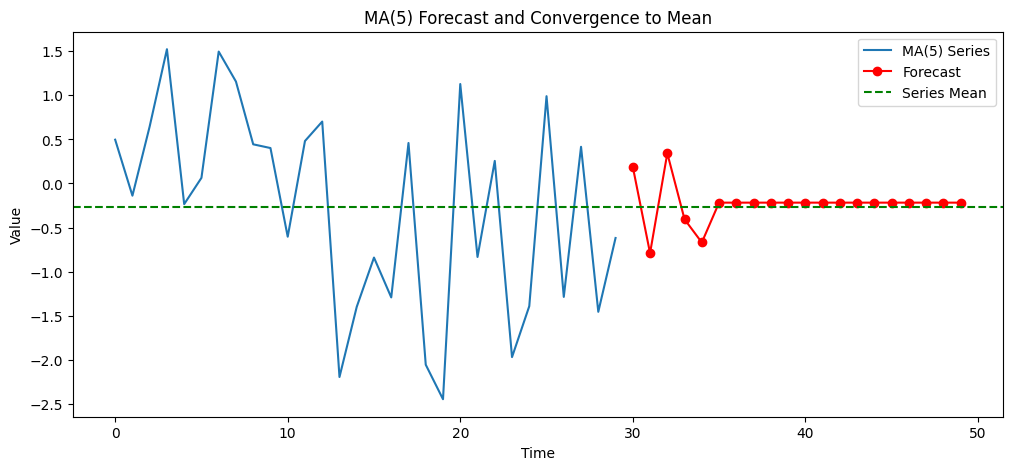

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Simulate MA(5) process
np.random.seed(42)
e = np.random.normal(size=30)
y = e + 0.6 * np.roll(e, 5)  # MA(5)
y[:5] = e[:5]  # Fix first values after roll

# Plot original MA(5) series
plt.figure(figsize=(12,5))
plt.plot(y, label="MA(5) Series")
plt.title("Simulated MA(5) Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

# Fit MA(5) model
model = ARIMA(y, order=(0,0,5))  # (p,d,q) with p=0, d=0, q=5
fit = model.fit()
print(fit.summary())

# Forecast next 20 steps
forecast_steps = 20
forecast = fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean

# Plot original series + forecast + convergence to mean
plt.figure(figsize=(12,5))
plt.plot(y, label="MA(5) Series")
plt.plot(np.arange(len(y), len(y)+forecast_steps), forecast_mean, 'r-o', label="Forecast")
# Plot mean line
mean_value = y.mean()
plt.axhline(mean_value, color='green', linestyle='--', label="Series Mean")
plt.title("MA(5) Forecast and Convergence to Mean")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()
